In [29]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import sys
sys.path.append("/var/home/maxpetzold/HUB_local/")
import pickle

import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.colors as col

from codebase.src.plots.pyplot import PyPlots
from codebase.src.statistics.distributions.Gamma import Gamma
from codebase.src.statistics.distributions.Normal import Normal
from codebase.src.statistics.distributions.Beta import Beta
from codebase.src.statistics.divergence.divergences import KL

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
df = pd.read_csv("../data/dry_weight/pflanzen_incl_ratio.csv")
df.head()

,Nr,Spross,Wurzel,ratio
0,1,13.3,8.8,0.601810
1,2,27.1,9.9,0.732432
2,3,0.9,0.3,0.750000
3,4,10.0,5.5,0.645161
4,5,11.8,4.2,0.737500


$\Large\text{Root-To-Sproot Ratio}$

Theoretical:

$\quad X_1 \sim Ga(x_1| \alpha_1, \beta)$, shown in previou section

$\quad X_2 \sim Ga(x_2| \alpha_2, \beta)$, shown in previou section

$\quad Y = \frac{X_1}{X_1 + X_2}$, transformation

$\quad Y \sim Be(y|\alpha_1, \alpha_2)$, under the assumption that $\beta_{root} = \beta_{sprout} = \beta$ and $X_1 \perp\!\!\!\perp X_2 $  (independent). This was proven in our lectures.  
- I can theoretically model the ratio with just the $\alpha$'s from the Gamma's


In [31]:
#
# import the parameters
#
params = pickle.load(open("02_params_gamma.pk", "rb"))
a_sprout, a_root = params["a_sprout"], params["a_root"]
print(a_sprout, a_root)

3.4580396428978006 2.091166007603795


In [32]:
beta = Beta()

In [33]:
x, y = beta.PDF(a=a_sprout, b=a_root, xmin=0, xmax=1.0)

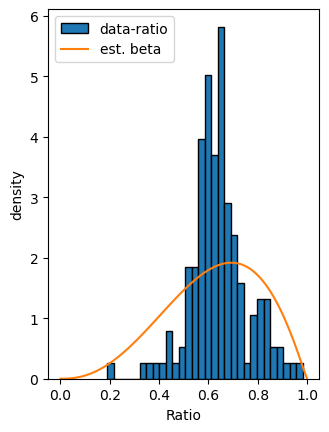

In [34]:
plots = PyPlots(1,1)
plots.hist(0,0, x=df.ratio, bins=30, label="data-ratio", xlabel="Ratio", ylabel="density")
plots.plot(0, 0, x=x, y=y, label="est. beta")
plots.display()
plots.savefig("../reports/images/03_ratio_beta_modelling.png", dpi=150)